# FX-Equity Performance

The overall goal of this strategy is to link the equity returns differential FX futures. The main approach is to find which equities outperform US equities and then trade FX Futures.

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
from   statsmodels.regression.rolling import RollingOLS

# Get Data

To calculate the equity returns differential the MSCI ETFs total return prices are used, then calculate the price returns, and take the difference. 

In [2]:
eq_path    = os.path.join("data", "ETFPX.parquet")
fut_path   = os.path.join("data", "FutPX.parquet")
guide_path = os.path.join("data", "ETFGuide.xlsx")

In [3]:
df_eq_spread = (pd.read_parquet(
    path = eq_path).
    pct_change().
    reset_index().
    melt(id_vars = ["SPY", "date"]).
    dropna().
    assign(spread = lambda x: x.value - x.SPY))

In [4]:
df_fut_rtn = (pd.read_parquet(
    path = fut_path).
    assign(security = lambda x: x.security.str.split("1").str[0]).
    pivot(index = "date", columns = "security", values = "PX_LAST").
    pct_change().
    reset_index().
    melt(id_vars = "date", value_name = "fut_rtn").
    dropna())

In [5]:
df_ticker_guide = (pd.read_excel(
    io = guide_path).
    query("group == 'liquid'").
    drop(columns = ["group"]).
    rename(columns = {
        "ticker"       : "fut_ticker",
        "etf_benchmark": "etf_ticker"}))

In [6]:
window    = 30
df_signal = (df_eq_spread.pivot(
    index = "date", columns = "ticker", values = "spread").
    apply(lambda x: (x - x.ewm(span = window, adjust = False).mean()) / x.ewm(span = window, adjust = False).std()).
    shift().
    reset_index().
    melt(id_vars = "date", var_name = "etf_ticker", value_name = "signal").
    dropna())

In [7]:
df_combined = (df_fut_rtn.rename(
    columns = {"security": "fut_ticker"}).
    assign(date = lambda x: pd.to_datetime(x.date).dt.date).
    merge(right = df_ticker_guide, how = "inner", on = ["fut_ticker"]).
    merge(right = df_signal, how = "inner", on = ["date", "etf_ticker"]))

# Trading Raw Z-Score

Start by calculating z-score of 30 and then generically apply that to the returns, and add a 10% volatility targetting. Both perfect and lagged volatility targetting are used to capture large intraday swings (if applicable)

In [8]:
df_zscore_rtn = (df_combined.assign(
    signal_rtn = lambda x: np.sign(x.signal) * x.fut_rtn).
    pivot(index = "date", columns = "fut_ticker", values = "signal_rtn"))

In [9]:
df_lagged = (df_zscore_rtn.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    dropna().
    assign(group = "lagged"))

df_perf = (df_zscore_rtn.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    dropna().
    assign(group = "perf"))

df_combined = pd.concat([df_lagged, df_perf])

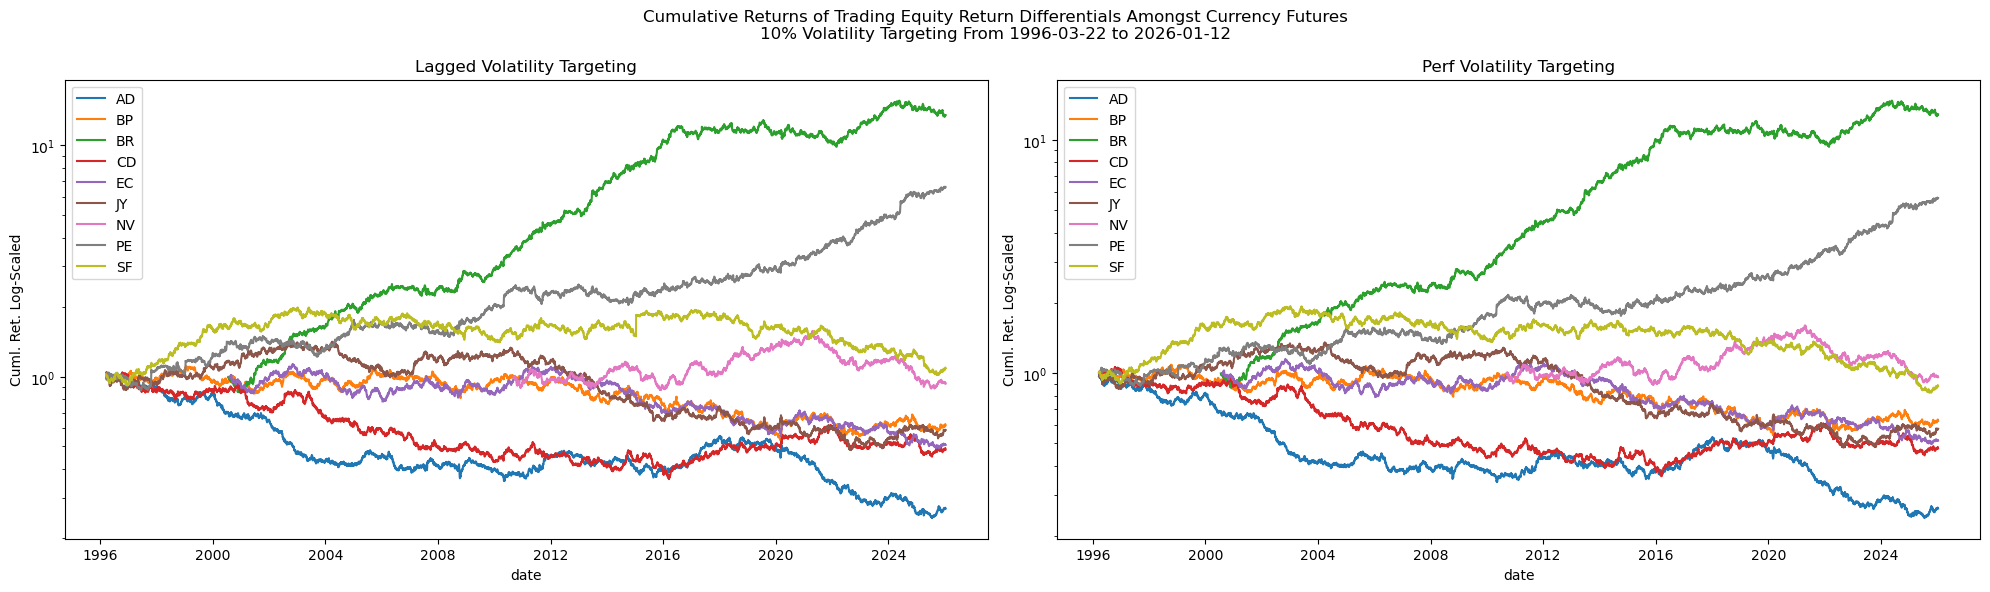

In [10]:
group_vars = df_combined.group.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars), figsize = (20,6))

for group_var, ax in zip(group_vars, axes.flatten()): 

    (df_combined.query(
        "group == @group_var").
        rename(columns = {"fut_ticker": ""}).
        pivot(index = "date", columns = "", values = "rtn").
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            ax     = ax,
            logy   = True,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = group_var.capitalize() + " Volatility Targeting"))

fig.suptitle("Cumulative Returns of Trading Equity Return Differentials Amongst Currency Futures\n10% Volatility Targeting From {} to {}".format(
    df_combined.date.min(),
    df_combined.date.max()))
plt.tight_layout()

Below are the sharpes per each future contract. While the results are not strong the consistency of the returns implores further analysis, that a model can be fit.

In [11]:
display(df_combined.drop(
    columns = ["date"]).
    groupby(["fut_ticker", "group"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {
        "group"     : "",
        "fut_ticker": "Fut Ticker"}).
    replace({
        "lagged": "Lagged Vol",
        "perf"  : "Perfect Vol"}).
    pivot(index = "", columns = "Fut Ticker", values = "rtn").
    apply(lambda x: np.round(x,3)))

Fut Ticker,AD,BP,BR,CD,EC,JY,NV,PE,SF
,,,,,,,,,
Lagged Vol,-0.384,-0.110,1.074,-0.192,-0.219,-0.125,0.006,0.671,0.080
Perfect Vol,-0.413,-0.114,1.091,-0.207,-0.222,-0.142,0.021,0.654,0.005


# Trading Z-Score Deciles

Start by calculating decile bins for the z-score and then calculating the sharpe per each bin. Then examine the outerbins 1st, 2nd, 9th, and 10th. To trade just ensure that the each upper or lower set of sharpe bins have a sharpe of the same sign.

In [12]:
df_decile = (df_eq_spread.pivot(
    index = "date", columns = "ticker", values = "spread").
    apply(lambda x: (x - x.ewm(span = window, adjust = False).mean()) / x.ewm(span = window, adjust = False).std()).
    apply(lambda x: pd.qcut(x = x, q = 10, labels = [i + 1 for i in range(10)])).
    shift().
    reset_index().
    melt(id_vars = "date", var_name = "etf_ticker", value_name = "decile").
    dropna())

In [13]:
df_combined = (df_fut_rtn.rename(
    columns = {"security": "fut_ticker"}).
    assign(date = lambda x: pd.to_datetime(x.date).dt.date).
    merge(right = df_ticker_guide, how = "inner", on = ["fut_ticker"]).
    merge(right = df_decile, how = "inner", on = ["date", "etf_ticker"]))

In [14]:
df_decile_sharpe = (df_combined.drop(
    columns = ["date", "name", "etf_ticker"]).
    groupby(["fut_ticker", "decile"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {"fut_rtn": "sharpe"}))

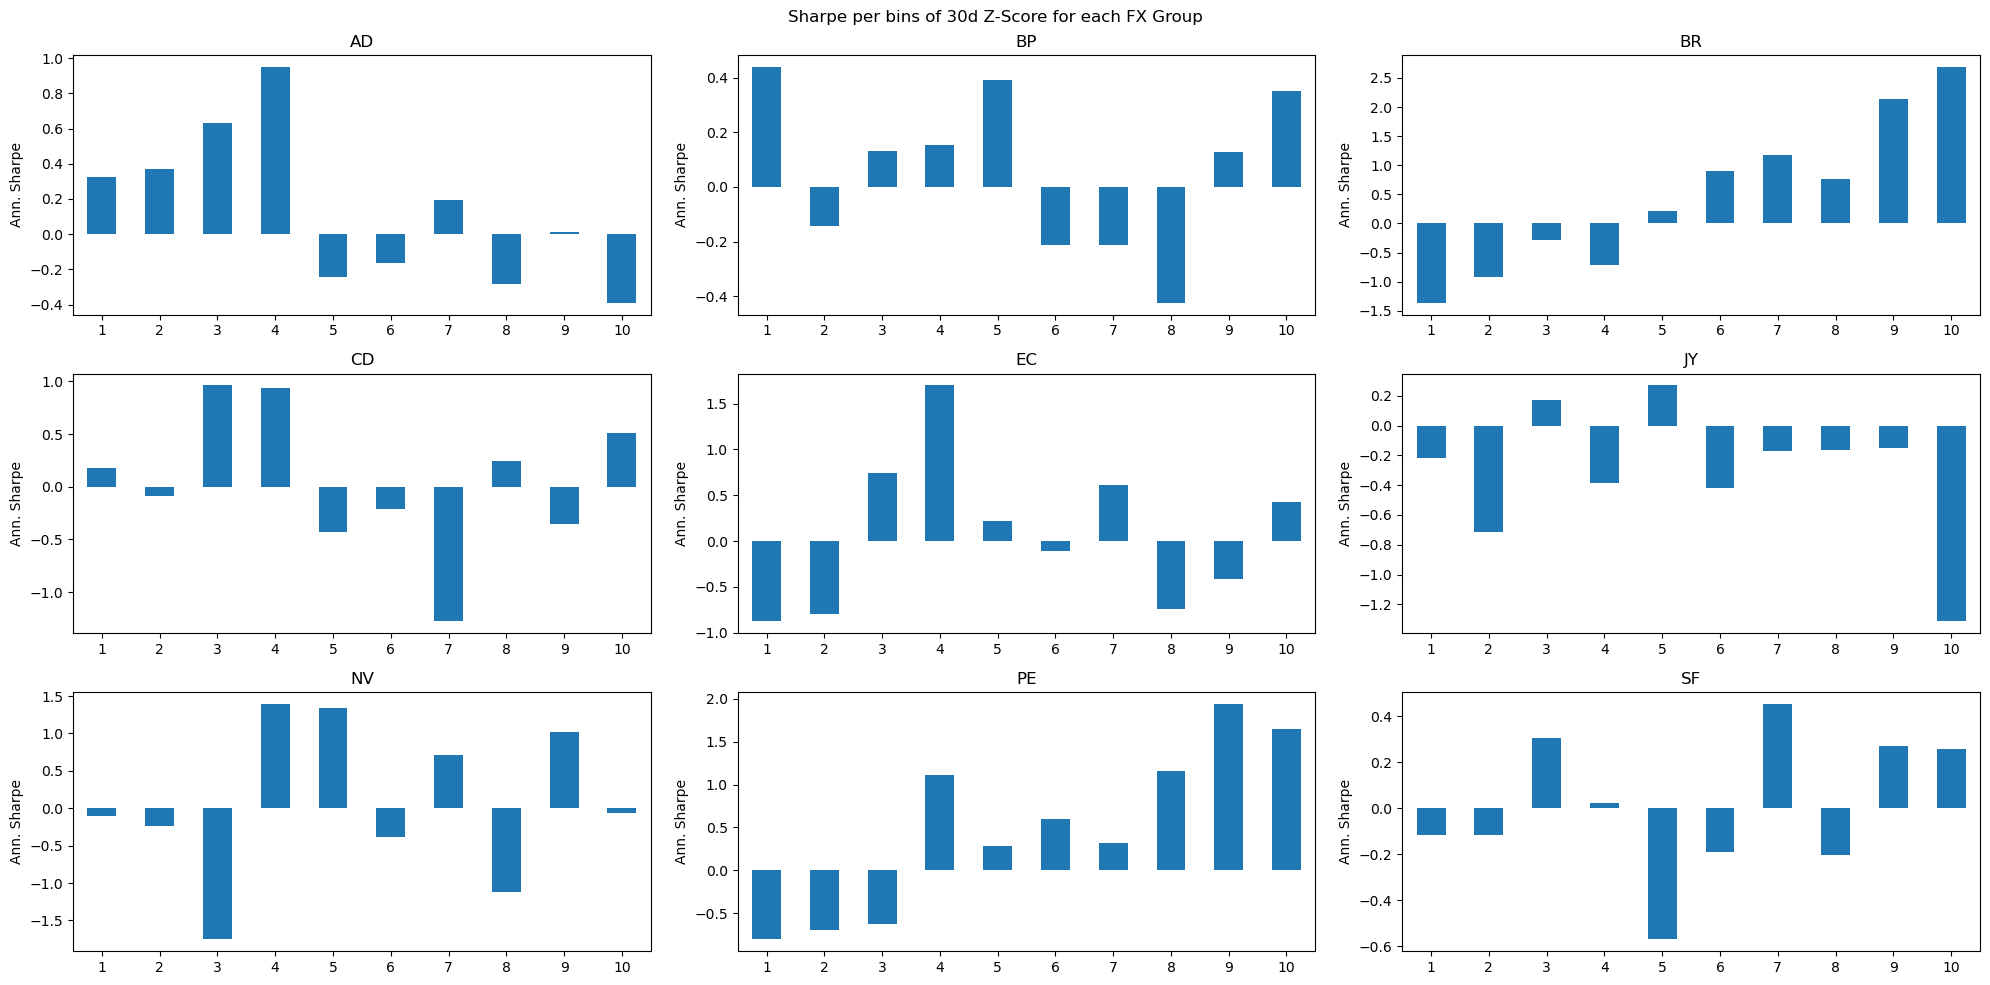

In [15]:
tickers = df_decile_sharpe.fut_ticker.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = 3, nrows = 3, figsize = (20,10))

for ticker, ax in zip(tickers, axes.flatten()):

    (df_decile_sharpe.query(
        "fut_ticker == @ticker").
        set_index("decile")
        [["sharpe"]].
        plot(
            kind   = "bar", 
            ax     = ax,
            legend = False,
            rot    = 0,
            xlabel = "",
            ylabel = "Ann. Sharpe",
            title  = ticker))

fig.suptitle("Sharpe per bins of 30d Z-Score for each FX Group")
plt.tight_layout()

In [16]:
df_decile_tmp = (df_decile_sharpe.query(
    "decile == [1,2,9,10]").
    assign(group = lambda x: np.where(x.decile <= 2, "lower_group", "upper_group")))

In [17]:
df_sig_map = (df_decile_tmp.drop(
    columns = ["decile"]).
    groupby(["fut_ticker", "group"]).
    agg("prod").
    reset_index().
    rename(columns = {"sharpe": "raw_scaler"}).
    merge(right = df_decile_tmp, how = "inner", on = ["fut_ticker", "group"]).
    assign(signal = lambda x: np.where(x.raw_scaler > 0.1, x.sharpe, 0))
    [["fut_ticker", "decile", "signal"]])

In [18]:
df_sig_rtn_tmp = (df_combined.merge(
    right = df_sig_map, how = "left", on = ["fut_ticker", "decile"]).
    assign(signal_rtn = lambda x: np.sign(x.signal) * x.fut_rtn))

In [19]:
df_sig_wider = (df_sig_rtn_tmp.pivot(
    index = "date", columns = "fut_ticker", values = "signal_rtn"))

In [20]:
df_lagged = (df_sig_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    dropna().
    assign(vol_group = "lagged"))

df_perf = (df_sig_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    dropna().
    assign(vol_group = "perfect"))

In [21]:
df_sig_rtn = (pd.concat([
    df_lagged, df_perf]))

Then to backtest the strategy set a 10% volatility target. 

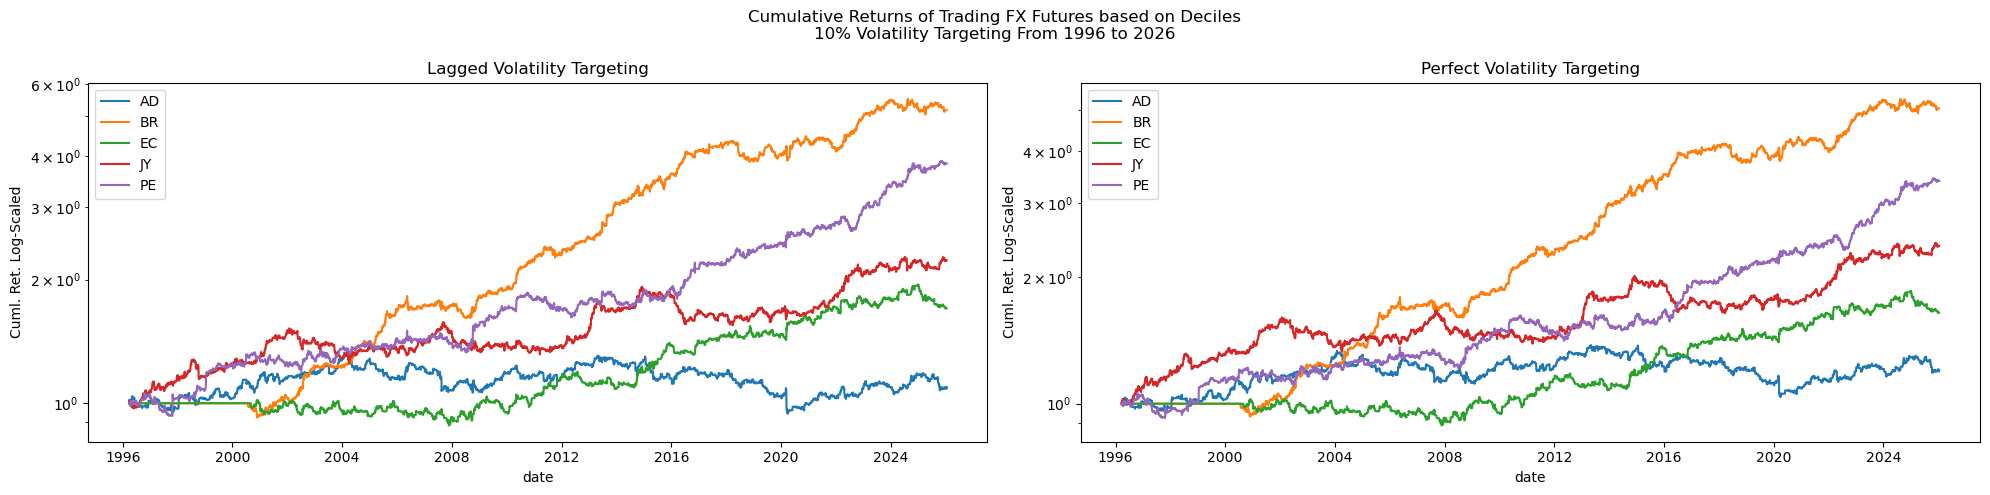

In [22]:
group_vars = df_sig_rtn.vol_group.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars), figsize = (20,5))

for group_var, ax in zip(group_vars, axes.flatten()): 

    (df_sig_rtn.query(
        "vol_group == @group_var").
        rename(columns = {"fut_ticker": ""}).
        pivot(index = "date", columns = "", values = "rtn").
        fillna(0).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            logy   = True,
            ax     = ax,
            title  = group_var.capitalize() + " Volatility Targeting",
            ylabel = "Cuml. Ret. Log-Scaled"))

fig.suptitle("Cumulative Returns of Trading FX Futures based on Deciles\n10% Volatility Targeting From {} to {}".format(
    df_sig_rtn.date.min().year,
    df_sig_rtn.date.max().year))

plt.tight_layout()
out_path = os.path.join("latex", "OptZScoreReturn.png")
fig.savefig(out_path, dpi = 300)

In [23]:
(df_sig_rtn.drop(
    columns = ["date"]).
    groupby(["fut_ticker", "vol_group"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    assign(vol_group = lambda x: x.vol_group.str.capitalize()).
    rename(columns = {
        "vol_group" : "Vol Target",
        "fut_ticker": ""}).
    pivot(index = "", columns = "Vol Target", values = "rtn").
    apply(lambda x: np.round(x,3)))

Vol Target,Lagged,Perfect
,,
AD,0.125,0.212
BR,1.638,1.697
EC,0.572,0.569
JY,0.714,0.796
PE,1.116,1.118


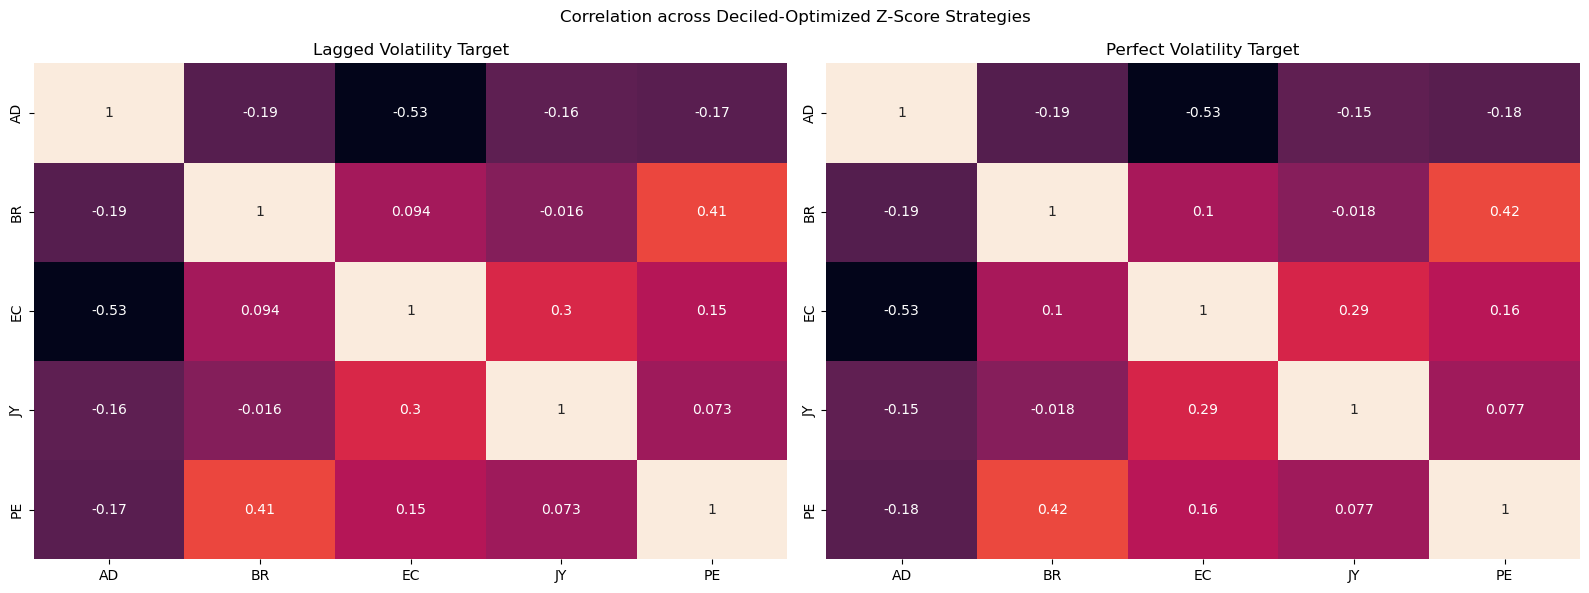

In [24]:
group_vars = df_sig_rtn.vol_group.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars), figsize = (16,6))

for group_var, ax in zip(group_vars, axes.flatten()): 

    df_corr = (df_sig_rtn.query(
        "vol_group == @group_var").
        rename(columns = {"fut_ticker": ""}).
        pivot(index = "date", columns = "", values = "rtn").
        corr().
        apply(lambda x: np.round(x,3)))

    (sns.heatmap(
        data  = df_corr,
        ax    = ax,
        cbar  = False,
        annot = True))

    ax.set_title(group_var.capitalize() + " Volatility Target")

fig.suptitle("Correlation across Deciled-Optimized Z-Score Strategies")
plt.tight_layout()

In [25]:
display(df_sig_rtn.rename(
    columns = {"rtn": "raw_rtn"}).
    assign(adj_rtn = lambda x: np.where(x.raw_rtn == 0, np.nan, x.raw_rtn)).
    melt(id_vars = ["date", "fut_ticker", "vol_group"]).
    dropna().
    drop(columns = ["date"]).
    groupby(["fut_ticker", "vol_group", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {
        "vol_group" : "Vol Target",
        "variable"  : "",
        "fut_ticker": "Fut"}).
    replace({
        "adj_rtn": "Adj Sharpe",
        "raw_rtn": "Raw Sharpe",
        "lagged" : "Lagged",
        "perfect": "Perfect"}).
    pivot(index = "Fut", columns = ["Vol Target", ""], values = "value").
    apply(lambda x: np.round(x,3)))

Vol Target     Lagged               Perfect           
           Adj Sharpe Raw Sharpe Adj Sharpe Raw Sharpe
Fut                                                   
AD              0.177      0.125      0.300      0.212
BR              1.661      1.638      1.721      1.697
EC              0.813      0.572      0.809      0.569
JY              0.718      0.714      0.801      0.796
PE              1.133      1.116      1.134      1.118

In [26]:
df_zscore_port = (df_sig_rtn.drop(
    columns = ["fut_ticker"]).
    query("rtn != 0").
    groupby(["date", "vol_group"]).
    agg("mean").
    reset_index())

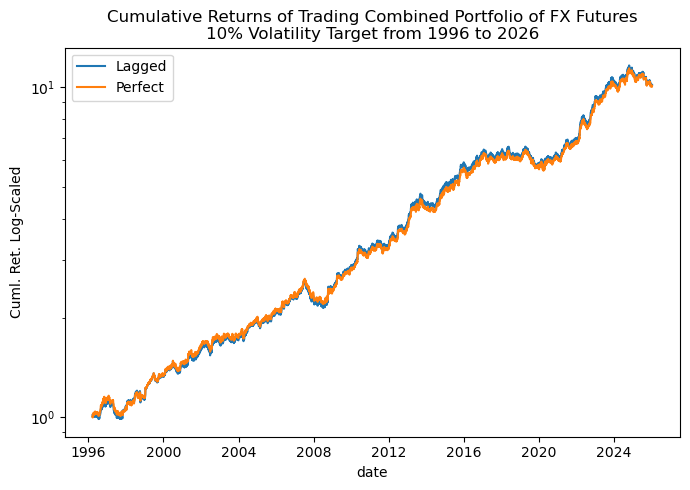

In [27]:
fig, axes = plt.subplots(figsize = (7,5))

(df_zscore_port.assign(
    vol_group = lambda x: x.vol_group.str.capitalize()).
    rename(columns = {"vol_group": ""}).
    pivot(index = "date", columns = "", values = "rtn").
    apply(lambda x: np.cumprod(1 + x)).
    plot(
        ax      = axes,
        logy    = True,
        ylabel  = "Cuml. Ret. Log-Scaled",
        title   = "Cumulative Returns of Trading Combined Portfolio of FX Futures\n10% Volatility Target from {} to {}".format(
            df_zscore_port.date.min().year,
            df_zscore_port.date.max().year)))

plt.tight_layout()
out_path = os.path.join("latex", "OptZScorePort.png")
fig.savefig(out_path, dpi = 300)

In [28]:
display(df_zscore_port.rename(columns = {
    "rtn": "raw_rtn"}).
    assign(adj_rtn = lambda x: np.where(x.raw_rtn != 0, x.raw_rtn, np.nan)).
    melt(id_vars = ["date", "vol_group"]).
    drop(columns = ["date"]).
    groupby(["vol_group", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    assign(vol_group = lambda x: x.vol_group.str.capitalize()).
    rename(columns = {
        "vol_group": "Vol Target",
        "variable" : ""}).
    pivot(index = "Vol Target", columns = "", values = "value").
    rename(columns = {
        "adj_rtn": "Adj Sharpe",
        "raw_rtn": "Raw Sharpe"}).
    apply(lambda x: np.round(x,3)))

,Adj Sharpe,Raw Sharpe
Vol Target,,
Lagged,1.119,1.119
Perfect,1.184,1.184


# Trading Residuals of Z-Score

For this strategy run a regressin of the z-score against the returns the main approach is to run 
\begin{equation}
r_t = \alpha + \beta \cdot z_t + \epsilon
\end{equation}

In [29]:
df_vol_rtn = (df_fut_rtn.pivot(
    index = "date", columns = "security", values = "fut_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "fut_rtn").
    dropna().
    assign(group = "vol_target"))

df_combined = (pd.concat([
    df_vol_rtn,
    df_fut_rtn.assign(group = "no_target")]).
    rename(columns = {"security": "fut_ticker"}).
    assign(date = lambda x: pd.to_datetime(x.date).dt.date).
    merge(right = df_ticker_guide, how = "inner", on = ["fut_ticker"]).
    merge(right = df_signal, how = "inner", on = ["date", "etf_ticker"]).
    assign(group_var = lambda x: x.fut_ticker + " " + x.group))

In [30]:
def _get_params(df: pd.DataFrame) -> pd.DataFrame:

    model = (sm.OLS(
        endog = df.fut_rtn,
        exog  = sm.add_constant(df.signal)).
        fit())

    df_params  = model.params.to_frame(name = "param_val").reset_index()
    df_pvalues = model.pvalues.to_frame(name = "p_value").reset_index()
    df_tstats  = model.tvalues.to_frame(name = "t_stat").reset_index()

    df_out = (df_params.merge(
        right = df_pvalues, how = "inner", on = ["index"]).
        merge(right = df_tstats, how = "inner", on = ["index"]))

    return df_out

(df_combined.groupby(
    "group_var").
    apply(_get_params).
    reset_index().
    drop(columns = ["level_1"]).
    rename(columns = {"index": "param"}).
    melt(id_vars = ["group_var", "param"]).
    assign(
        ticker = lambda x: x.group_var.str.split(" ").str[0],
        target = lambda x: x.group_var.str.split(" ").str[1]).
    rename(columns = {
        "variable": "",
        "param"   : "Param",
        "ticker"  : "Ticker",
        "target"  : "Target"}).
    replace({
        "no_target" : "No Target",
        "param_val" : "Param Val",
        "p_value"   : r"$p$-value",
        "t_stat"    : r"$t$-stat",
        "vol_target": "Vol Target",
        "const"     : r"$\alpha$",
        "signal"    : "Z-Score"}).
    pivot(index = ["Ticker", "Target"], columns = ["", "Param"], values = "value").
    apply(lambda x: np.round(x,4)))

Param Val         $p$-value         $t$-stat        
Param              $\alpha$ Z-Score  $\alpha$ Z-Score $\alpha$ Z-Score
Ticker Target                                                         
AD     No Target     0.0001 -0.0001    0.4709  0.1808   0.7210 -1.3384
       Vol Target    0.0000 -0.0001    0.7574  0.1130   0.3089 -1.5850
BP     No Target     0.0000 -0.0000    0.7450  0.8745   0.3252 -0.1579
       Vol Target    0.0000 -0.0001    0.5473  0.4500   0.6019 -0.7555
BR     No Target     0.0003  0.0008    0.0204  0.0000   2.3191  5.9876
       Vol Target    0.0001  0.0005    0.0575  0.0000   1.8999  5.7306
CD     No Target     0.0000 -0.0000    0.7744  0.7839   0.2867 -0.2742
       Vol Target   -0.0000  0.0000    0.6989  0.9897  -0.3868  0.0129
EC     No Target     0.0000  0.0000    0.6756  0.5404   0.4185  0.6123
       Vol Target    0.0000  0.0000    0.8577  0.9223   0.1793  0.0975
JY     No Target    -0.0001 -0.0001    0.0807  0.1825  -1.7467 -1.3332
       Vol Target   -0.0002 -0.0001    0.0048  0.1756  -2.8202 -1.3547
NV     No Target     0.0000  0.0001    0.8094  0.4335   0.2412  0.7833
       Vol Target   -0.0000  0.0001    0.8723  0.3538  -0.1608  0.9273
PE     No Target     0.0002  0.0004    0.0142  0.0000   2.4515  4.8033
       Vol Target    0.0002  0.0003    0.0026  0.0000   3.0096  4.3946
SF     No Target     0.0000  0.0001    0.8737  0.4176   0.1590  0.8106
       Vol Target    0.0000  0.0000    0.9672  0.7535   0.0411  0.3140

In [31]:
df_combined = (df_fut_rtn.rename(
    columns = {"security": "fut_ticker"}).
    assign(date = lambda x: pd.to_datetime(x.date).dt.date).
    merge(right = df_ticker_guide, how = "inner", on = ["fut_ticker"]).
    merge(right = df_signal, how = "inner", on = ["date", "etf_ticker"]))

In [32]:
def _get_resid(df: pd.DataFrame) -> pd.DataFrame: 

    df_out = (sm.OLS(
        endog = df.fut_rtn,
        exog  = sm.add_constant(df.signal)).
        fit().
        resid.
        to_frame(name = "resid").
        assign(
            lag_resid = lambda x: x.resid.shift(),
            decile    = lambda x: pd.qcut(x = x.resid, q = 10, labels = [i + 1 for i in range(10)]).shift()).
        dropna().
        merge(right = df, how = "inner", on = ["date"]))

    return df_out

df_ols = (df_combined.assign(
    group_var = lambda x: x.fut_ticker + " " + x.etf_ticker).
    set_index("date").
    groupby("group_var").
    apply(_get_resid, include_groups = False).
    reset_index().
    assign(signal_rtn = lambda x: -np.sign(x.lag_resid) * x.fut_rtn))

In [33]:
df_lagged = (df_ols.pivot(
    index = "date", columns = "fut_ticker", values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    assign(group = "lagged"))

In [34]:
df_perf = (df_ols.pivot(
    index = "date", columns = "fut_ticker", values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    assign(group = "perfect"))

In [35]:
df_combined = (pd.concat([df_perf, df_lagged]))

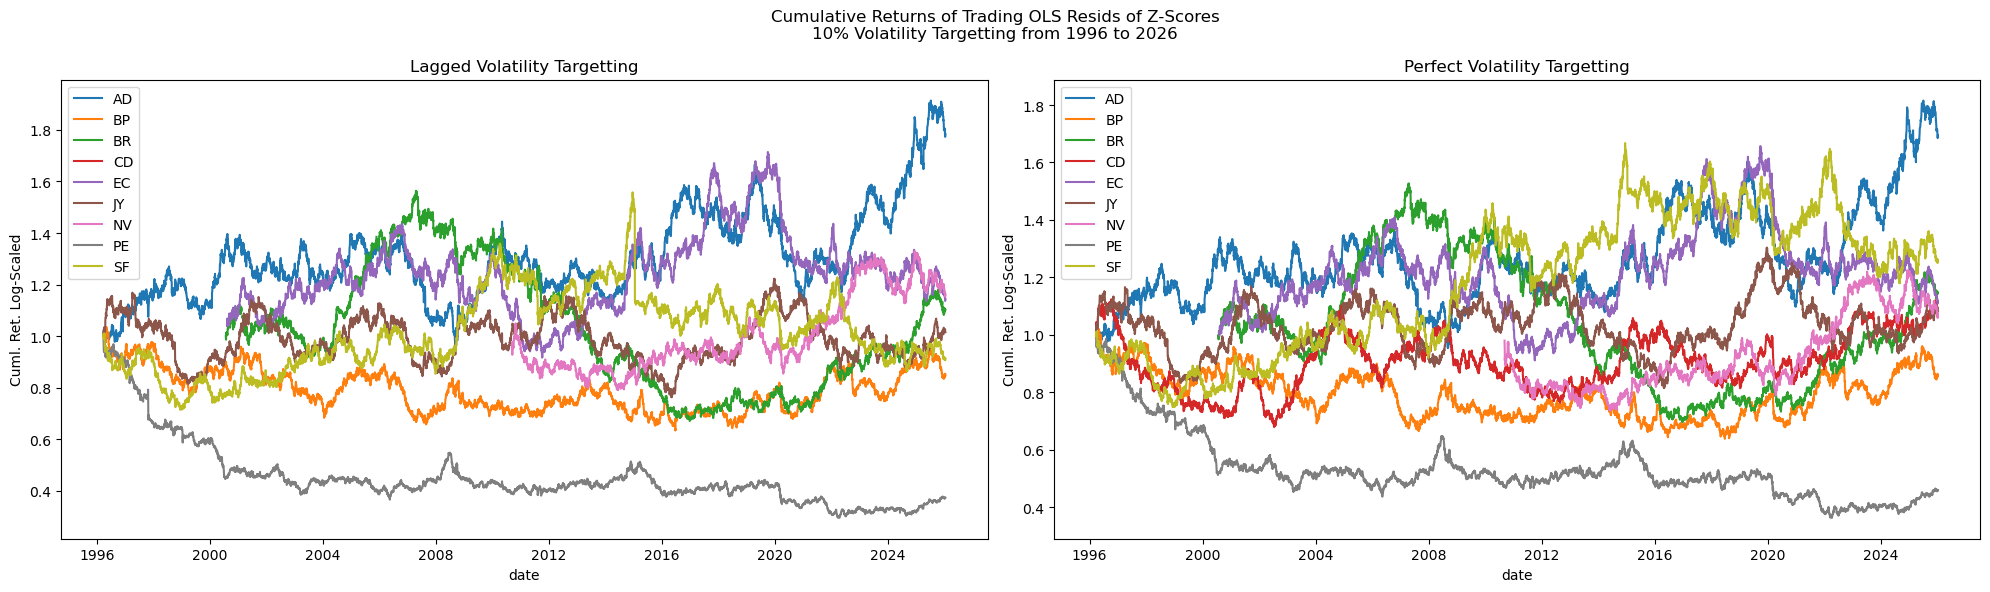

In [36]:
group_vars = df_combined.group.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars), figsize = (20,6))

for group_var, ax in zip(group_vars, axes.flatten()):

    (df_combined.query(
        "group == @group_var").
        rename(columns = {"fut_ticker": ""}).
        pivot(index = "date", columns = "", values = "rtn").
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            ax = ax,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = group_var.capitalize() + " Volatility Targetting"))

fig.suptitle("Cumulative Returns of Trading OLS Resids of Z-Scores\n10% Volatility Targetting from {} to {}".format(
    df_combined.date.min().year,
    df_combined.date.max().year))

plt.tight_layout()

# Trading Residuals Deciles

Now using the same approach as before decile the residuals and then trade the outer deciles if they have the same sign sharpe.

In [37]:
df_decile_sharpe = (df_ols[
    ["fut_ticker", "decile", "fut_rtn"]].
    groupby(["fut_ticker", "decile"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {"fut_rtn": "sharpe"}))

In [38]:
df_decile_tmp = (df_decile_sharpe.query(
    "decile == [1,2,9,10]").
    assign(group = lambda x: np.where(x.decile <= 2, "lgroup", "ugroup")))

In [39]:
df_opt_rtn = (df_decile_tmp.drop(
    columns = ["decile"]).
    groupby(["fut_ticker", "group"]).
    agg("prod").
    reset_index().
    assign(signal_scaler = lambda x: np.where(x.sharpe > 0, 1, 0)).
    drop(columns = ["sharpe"]).
    merge(right = df_decile_tmp, how = "outer", on = ["fut_ticker", "group"]).
    merge(right = df_ols, how = "inner", on = ["fut_ticker", "decile"]).
    assign(signal_rtn = lambda x: np.sign(x.sharpe * x.signal_scaler) * x.fut_rtn))

In [40]:
df_lagged = (df_opt_rtn.pivot(
    index = "date", columns = "fut_ticker", values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    assign(group = "lagged"))

df_perf = (df_opt_rtn.pivot(
    index = "date", columns = "fut_ticker", values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    assign(group = "perfect"))

In [41]:
df_combined = pd.concat([df_lagged, df_perf])

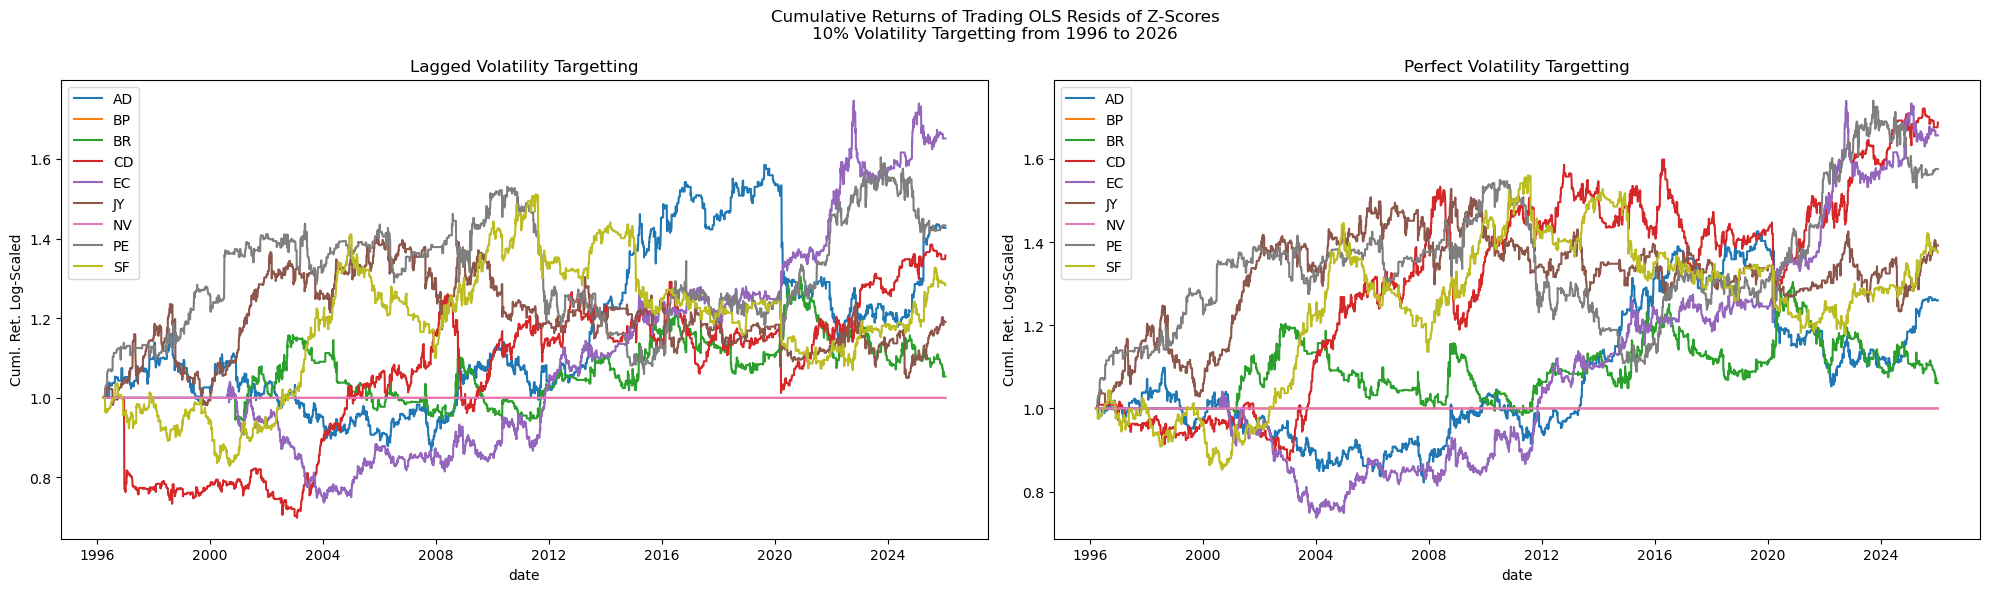

In [42]:
group_vars = df_combined.group.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars), figsize = (20,6))

for group_var, ax in zip(group_vars, axes.flatten()):

    (df_combined.query(
        "group == @group_var").
        rename(columns = {"fut_ticker": ""}).
        pivot(index = "date", columns = "", values = "rtn").
        fillna(0).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            ax = ax,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = group_var.capitalize() + " Volatility Targetting"))

fig.suptitle("Cumulative Returns of Trading OLS Resids of Z-Scores\n10% Volatility Targetting from {} to {}".format(
    df_combined.date.min().year,
    df_combined.date.max().year))

plt.tight_layout()
out_path = os.path.join("latex", "OptOLSResidrtn.png")
fig.savefig(out_path, dpi = 300)

In [43]:
display(df_combined.rename(
    columns = {"rtn": "adj_rtn"}).
    assign(raw_rtn = lambda x: np.where(x.adj_rtn != x.adj_rtn, 0, x.adj_rtn)).
    melt(id_vars = ["date", "fut_ticker", "group"]).
    dropna().
    drop(columns = ["date"]).
    groupby(["fut_ticker", "group", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    assign(group = lambda x: x.group.str.capitalize()).
    rename(columns = {
        "group"     : "Vol. Target",
        "variable"  : "",
        "fut_ticker": "Future"}).
    replace({
        "adj_rtn": "Adj Sharpe",
        "raw_rtn": "Raw Sharpe"}).
    pivot(index = "Future", columns = ["Vol. Target", ""], values = "value").
    apply(lambda x: np.round(x,3)))

C:\Users\Diego\AppData\Local\Temp\ipykernel_10104\2409452263.py:8: RuntimeWarning: invalid value encountered in scalar divide
  agg(lambda x: x.mean() / x.std() * np.sqrt(252)).


Vol. Target     Lagged               Perfect           
            Adj Sharpe Raw Sharpe Adj Sharpe Raw Sharpe
Future                                                 
AD               0.335      0.220      0.251      0.165
BP                 NaN        NaN        NaN        NaN
BR               0.102      0.062      0.110      0.066
CD               0.274      0.180      0.503      0.331
EC               0.542      0.329      0.559      0.340
JY               0.192      0.126      0.342      0.225
NV                 NaN        NaN        NaN        NaN
PE               0.339      0.222      0.449      0.294
SF               0.254      0.167      0.329      0.216

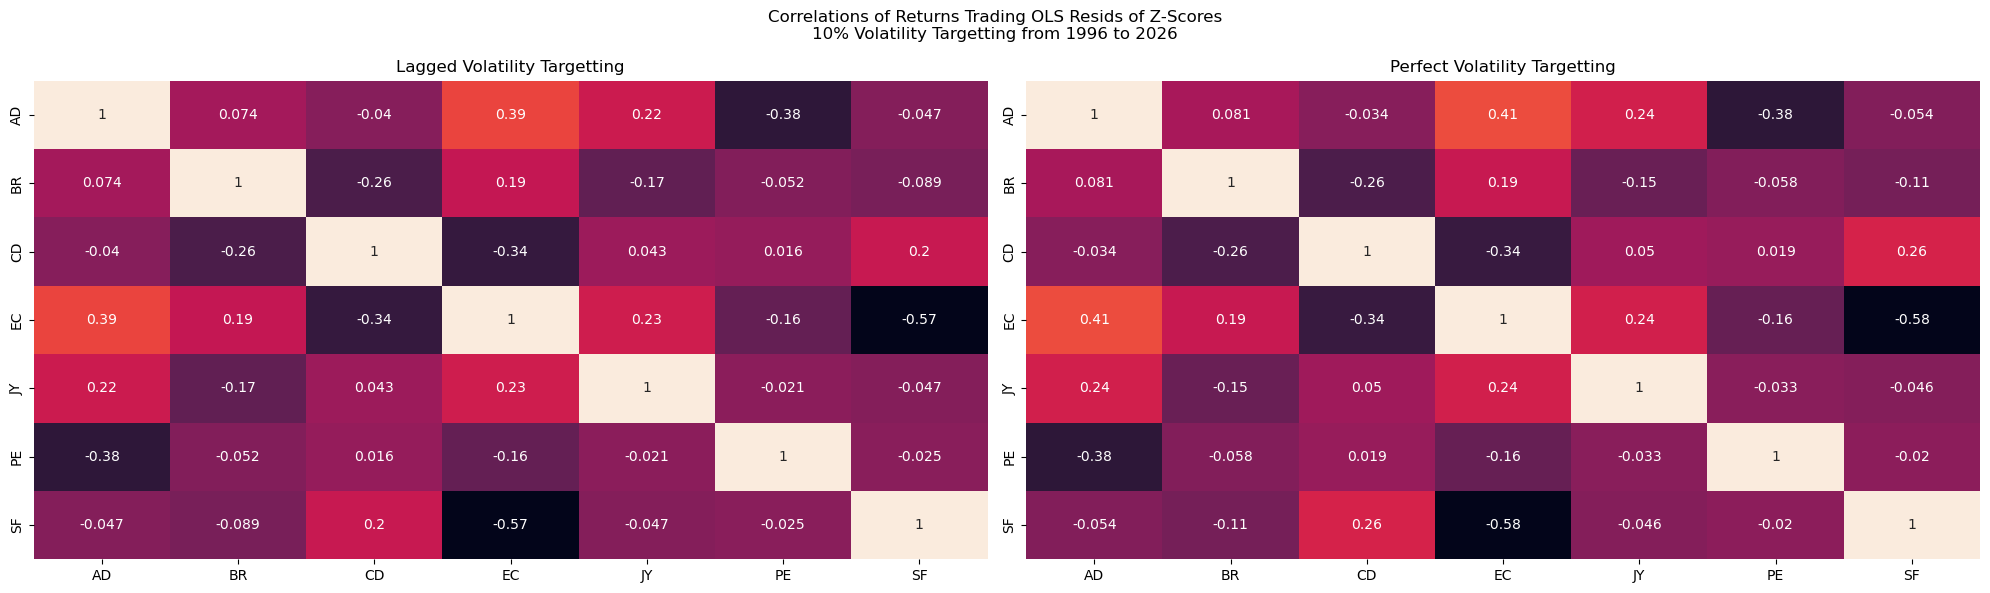

In [44]:
group_vars = df_combined.group.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars), figsize = (20,6))

for group_var, ax in zip(group_vars, axes.flatten()):

    df_corr = (df_combined.query(
        "group == @group_var").
        dropna().
        rename(columns = {"fut_ticker": ""}).
        pivot(index = "date", columns = "", values = "rtn").
        corr())

    sns.heatmap(
        data  = df_corr,
        ax    = ax,
        cbar  = False,
        annot = True)

    ax.set_title(group_var.capitalize() + " Volatility Targetting")

fig.suptitle("Correlations of Returns Trading OLS Resids of Z-Scores\n10% Volatility Targetting from {} to {}".format(
    df_combined.date.min().year,
    df_combined.date.max().year))

plt.tight_layout()

In [45]:
df_resid_port = (df_combined.drop(
    columns = ["fut_ticker"]).
    dropna().
    groupby(["date", "group"]).
    agg("mean").
    reset_index())

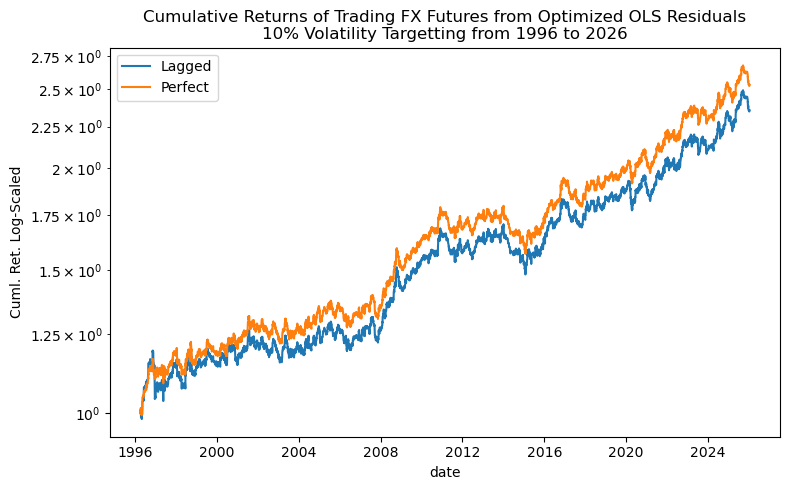

In [46]:
fig, axes = plt.subplots(figsize = (8,5))

(df_resid_port.assign(
    group = lambda x: x.group.str.capitalize()).
    rename(columns = {"group": ""}).
    pivot(index = "date", columns = "", values = "rtn").
    apply(lambda x: np.cumprod(1 + x)).
    plot(
        ax      = axes,
        logy    = True,
        ylabel  = "Cuml. Ret. Log-Scaled",
        title   = "Cumulative Returns of Trading FX Futures from Optimized OLS Residuals\n10% Volatility Targetting from {} to {}".format(
            df_resid_port.date.min().year,
            df_resid_port.date.max().year)))

plt.tight_layout()

In [47]:
display(df_resid_port.pivot(
    index = "date", columns = "group", values = "rtn").
    fillna(0).
    reset_index().
    melt(id_vars = "date", value_name = "raw_rtn").
    assign(adj_rtn = lambda x: np.where(x.raw_rtn != 0, x.raw_rtn, np.nan)).
    melt(id_vars = ["date", "group"]).
    dropna().
    drop(columns = ["date"]).
    groupby(["group", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    assign(group = lambda x: x.group.str.capitalize()).
    rename(columns = {"variable": ""}).
    pivot(index = "group", columns = "", values = "value").
    apply(lambda x: np.round(x,3)).
    rename(columns = {
        "adj_rtn": "Adj Sharpe",
        "raw_rtn": "Raw Rtn"}))

,Adj Sharpe,Raw Rtn
group,,
Lagged,0.548,0.502
Perfect,0.650,0.596


# Combining Portfolios

In [48]:
df_combined = (df_resid_port.rename(columns = {
    "group": "vol_group",
    "rtn"  : "resid_rtn"}).
    merge(right = df_zscore_port, how = "inner", on = ["date", "vol_group"]).
    rename(columns = {"rtn": "zscore_rtn"}))

In [49]:
(df_combined.drop(
    columns = ["date"]).
    groupby("vol_group").
    agg("corr").
    reset_index().
    query("resid_rtn != 1").
    assign(vol_group = lambda x: x.vol_group.str.capitalize()).
    rename(columns = {"vol_group": "Vol. Target"}).
    set_index("Vol. Target")
    [["resid_rtn"]].
    rename(columns = {"resid_rtn": "Correlation"}).
    apply(lambda x: np.round(x,3)))

,Correlation
Vol. Target,
Lagged,0.188
Perfect,0.195


In [50]:
df_combo_port = (df_combined.set_index([
    "date", "vol_group"]).
    assign(combined = lambda x: x.mean(axis = 1)).
    reset_index().
    melt(id_vars = ["date", "vol_group"]))

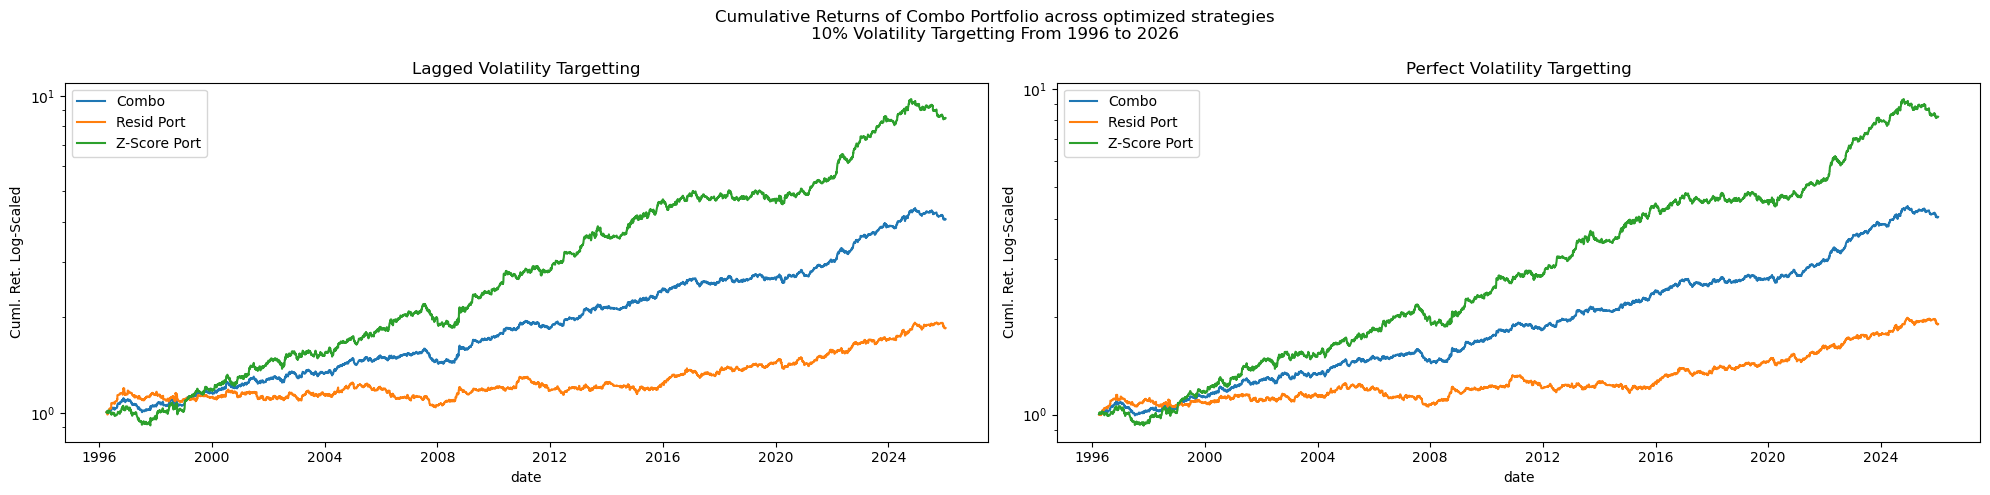

In [51]:
groups = df_combo_port.vol_group.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(groups), figsize = (20,5))

renamer = {
    "combined"  : "Combo",
    "resid_rtn" : "Resid Port",
    "zscore_rtn": "Z-Score Port"}

for group, ax in zip(groups, axes.flatten()):

    (df_combo_port.query(
        "vol_group == @group").
        rename(columns = {"variable": ""}).
        pivot(index = "date", columns = "", values = "value").
        apply(lambda x: np.cumprod(1 + x)).
        rename(columns = renamer).
        plot(
            logy   = True,
            ax     = ax,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = group.capitalize() + " Volatility Targetting"))

fig.suptitle("Cumulative Returns of Combo Portfolio across optimized strategies\n10% Volatility Targetting From {} to {}".format(
    df_combo_port.date.min().year,
    df_combo_port.date.max().year))

plt.tight_layout()

In [52]:
display(df_combo_port.assign(
    adj_val = lambda x: np.where(x.value != 0, x.value, np.nan)).
    rename(columns = {
        "variable": "port",
        "value"   : "raw_val"}).
    melt(id_vars = ["date", "vol_group", "port"]).
    drop(columns = ["date"]).
    groupby(["vol_group", "port", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    assign(vol_group = lambda x: x.vol_group.str.capitalize()).
    rename(columns = {
        "variable" : "",
        "vol_group": "Vol. Target",
        "port"     : "Strategy"}).
    replace({
        "adj_val"   : "Adj Sharpe",
        "raw_val"   : "Raw Sharpe",
        "combined"  : "Combo",
        "resid_rtn" : "Resid Port",
        "zscore_rtn": "Z-Score Port"}).
    pivot(index = ["Strategy", "Vol. Target"], columns = "", values = "value").
    apply(lambda x: np.round(x,3)).
    reset_index().
    set_index("Strategy"))

,Vol. Target,Adj Sharpe,Raw Sharpe
Strategy,,,
Combo,Lagged,1.109,1.109
Combo,Perfect,1.175,1.175
Resid Port,Lagged,0.514,0.474
Resid Port,Perfect,0.571,0.527
Z-Score Port,Lagged,1.141,1.141
Z-Score Port,Perfect,1.193,1.193
